# Credit Card Fraud Detection

This notebook covers:
1. Data loading & exploration
2. Handling extreme class imbalance
3. Baseline + advanced models
4. Proper evaluation (not accuracy!)
5. Feature importance / interpretability
6. Saving the final model


## 1. Setup & Data Loading

In [1]:
!pip install -q imbalanced-learn xgboost shap


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_recall_curve, roc_curve, f1_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
RANDOM_STATE = 42


In [5]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [6]:
path = 'creditcard.csv'
df = pd.read_csv(path)
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Exploratory Data Analysis (EDA)


Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


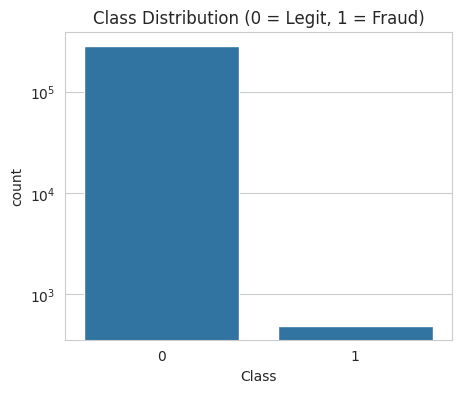

In [7]:
print(df['Class'].value_counts())
print()
print(df['Class'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x='Class', data=df, ax=ax)
ax.set_title('Class Distribution (0 = Legit, 1 = Fraud)')
ax.set_yscale('log')
plt.show()


Missing values per column:
 0


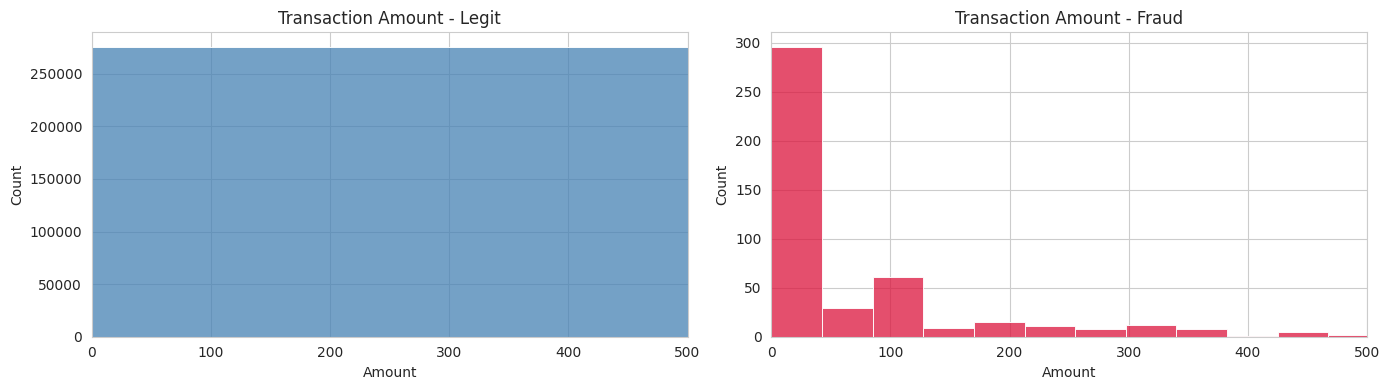

In [8]:
print("Missing values per column:\n", df.isnull().sum().sum())

fig, axes = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(df[df['Class']==0]['Amount'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Transaction Amount - Legit')
axes[0].set_xlim(0, 500)

sns.histplot(df[df['Class']==1]['Amount'], bins=50, ax=axes[1], color='crimson')
axes[1].set_title('Transaction Amount - Fraud')
axes[1].set_xlim(0, 500)
plt.tight_layout()
plt.show()


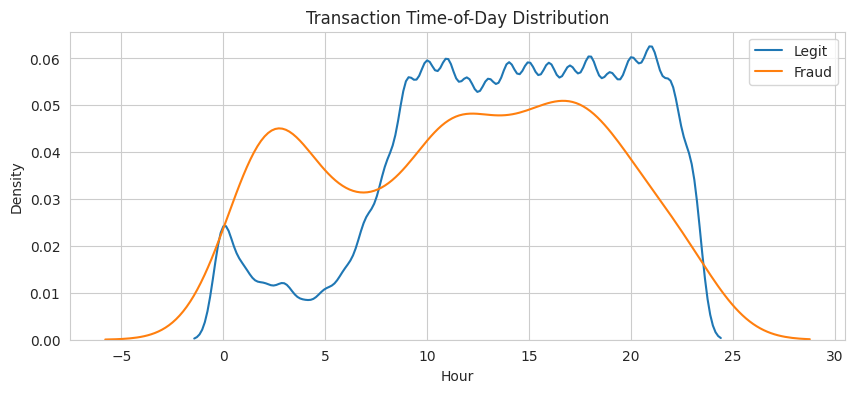

In [9]:
df['Hour'] = (df['Time'] // 3600) % 24

fig, ax = plt.subplots(figsize=(10,4))
sns.kdeplot(df[df['Class']==0]['Hour'], label='Legit', ax=ax)
sns.kdeplot(df[df['Class']==1]['Hour'], label='Fraud', ax=ax)
ax.set_title('Transaction Time-of-Day Distribution')
ax.legend()
plt.show()


## 3. Preprocessing

- `V1`-`V28` are already PCA-transformed and scaled.
- `Amount` and `Time` are NOT scaled — we need to fix that.
- Split into train/test **before** any resampling to avoid data leakage.


In [10]:
df_model = df.drop(columns=['Hour'])

X = df_model.drop(columns=['Class'])
y = df_model['Class']

# Scale Amount and Time (V1-V28 are already scaled via PCA)
amount_scaler = StandardScaler()
time_scaler = StandardScaler()
X['Amount'] = amount_scaler.fit_transform(X[['Amount']])
X['Time'] = time_scaler.fit_transform(X[['Time']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "Fraud cases:", y_train.sum())
print("Test shape:", X_test.shape, "Fraud cases:", y_test.sum())


Train shape: (227845, 30) Fraud cases: 394
Test shape: (56962, 30) Fraud cases: 98


## 4. Handling Class Imbalance with SMOTE

We apply SMOTE **only on the training set** (never on test data — that would leak
synthetic fraud patterns into evaluation and inflate your scores unrealistically).


In [11]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())


Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


## 5. Evaluation Helper

In [12]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
    print("PR-AUC (Average Precision):", round(average_precision_score(y_test, y_proba), 4))

    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(11,4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
    axes[0].set_title(f'{name} - Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    axes[1].plot(recall, precision)
    axes[1].set_title(f'{name} - Precision-Recall Curve')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')

    plt.tight_layout()
    plt.show()

    return {
        'model': name,
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba),
        'f1': f1_score(y_test, y_pred)
    }

results = []


## 6. Baseline: Logistic Regression

===== Logistic Regression (SMOTE) =====
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9698
PR-AUC (Average Precision): 0.7249


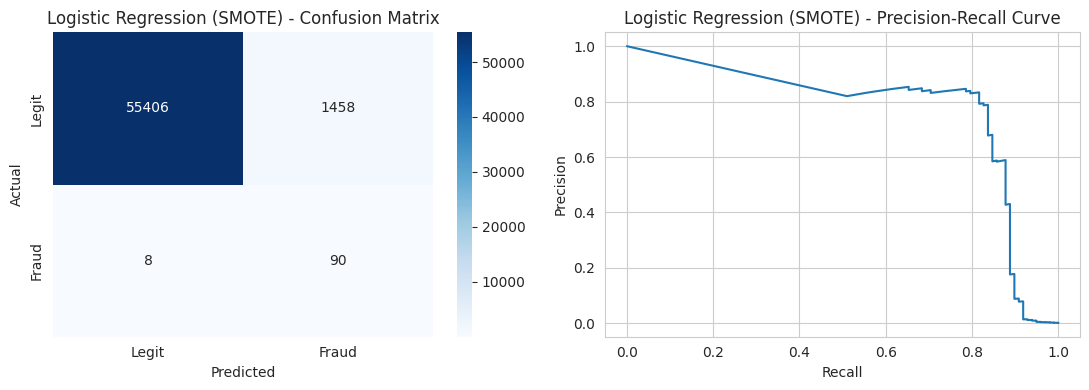

In [13]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_res, y_train_res)
results.append(evaluate_model("Logistic Regression (SMOTE)", log_reg, X_test, y_test))


## 7. Random Forest

===== Random Forest (SMOTE) =====
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.54      0.85      0.66        98

    accuracy                           1.00     56962
   macro avg       0.77      0.92      0.83     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9822
PR-AUC (Average Precision): 0.8353


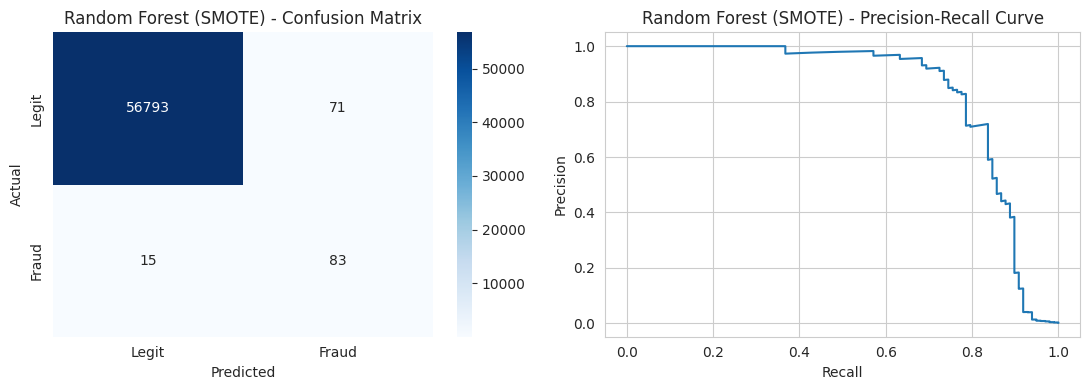

In [14]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_res, y_train_res)
results.append(evaluate_model("Random Forest (SMOTE)", rf, X_test, y_test))


## 8. XGBoost



===== XGBoost (SMOTE) =====
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.69      0.86      0.77        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9811
PR-AUC (Average Precision): 0.8668


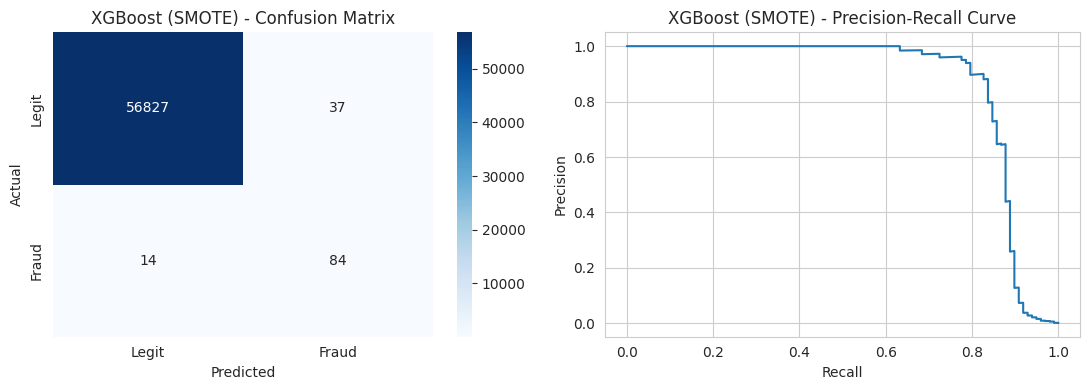

In [15]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_model.fit(X_train_res, y_train_res)
results.append(evaluate_model("XGBoost (SMOTE)", xgb_model, X_test, y_test))


===== XGBoost (class_weight, no SMOTE) =====
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.89      0.85      0.87        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9673
PR-AUC (Average Precision): 0.8852


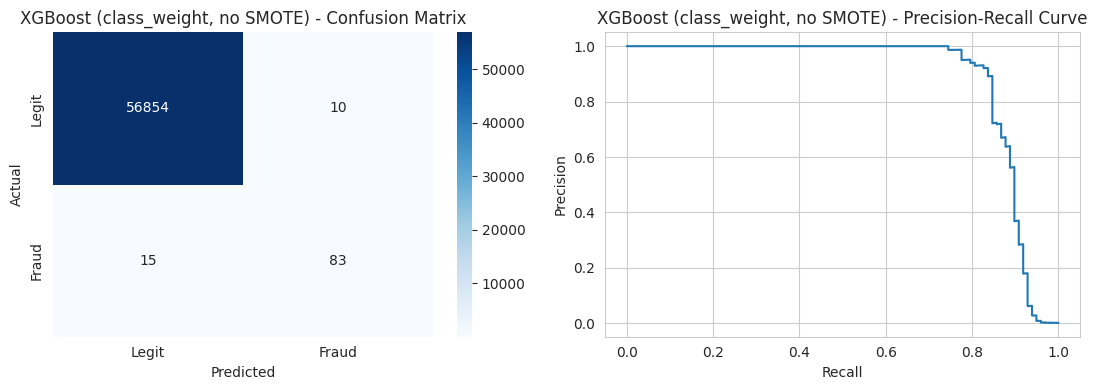

In [16]:
# Alternative: XGBoost without SMOTE, using class weighting instead
neg, pos = np.bincount(y_train)
xgb_weighted = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=neg/pos,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_weighted.fit(X_train, y_train)
results.append(evaluate_model("XGBoost (class_weight, no SMOTE)", xgb_weighted, X_test, y_test))


## 9. Compare All Models

In [17]:
results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False)
results_df


,model,roc_auc,pr_auc,f1
3,"XGBoost (class_weight, no SMOTE)",0.967280,0.885162,0.869110
2,XGBoost (SMOTE),0.981149,0.866816,0.767123
1,Random Forest (SMOTE),0.982170,0.835323,0.658730
0,Logistic Regression (SMOTE),0.969848,0.724861,0.109356


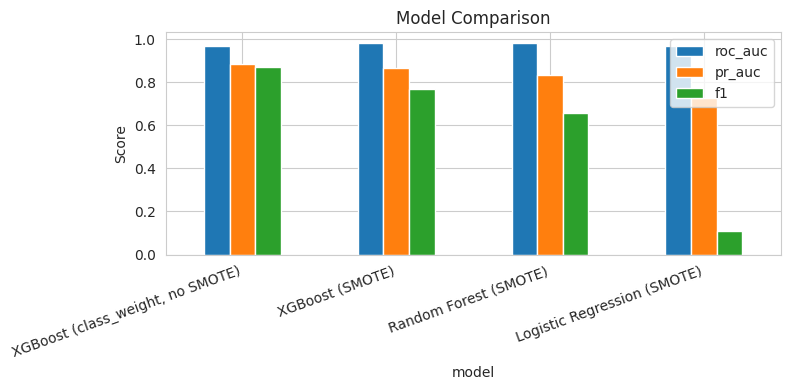

In [18]:
fig, ax = plt.subplots(figsize=(8,4))
results_df.set_index('model')[['roc_auc','pr_auc','f1']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison')
ax.set_ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


## 10. Feature Importance (Best Model)



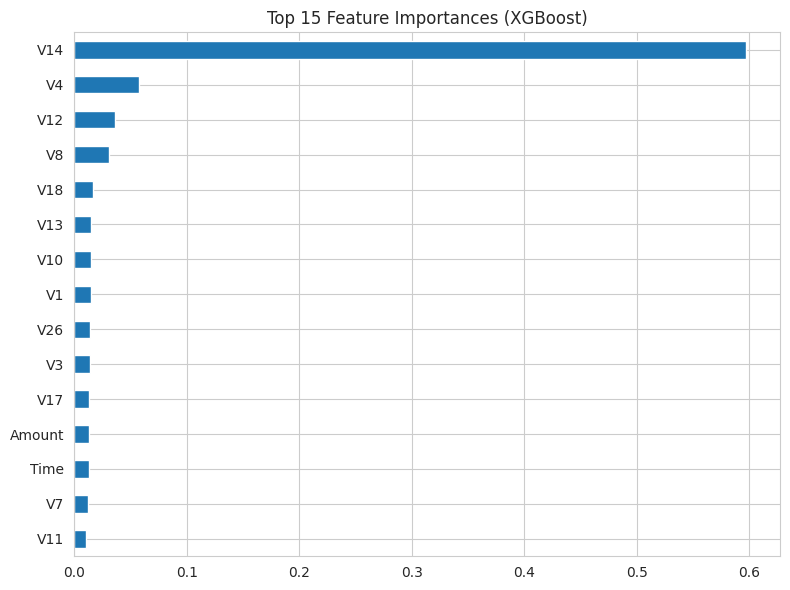

In [19]:
best_model = xgb_model

importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,6))
importances.head(15).plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Top 15 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()


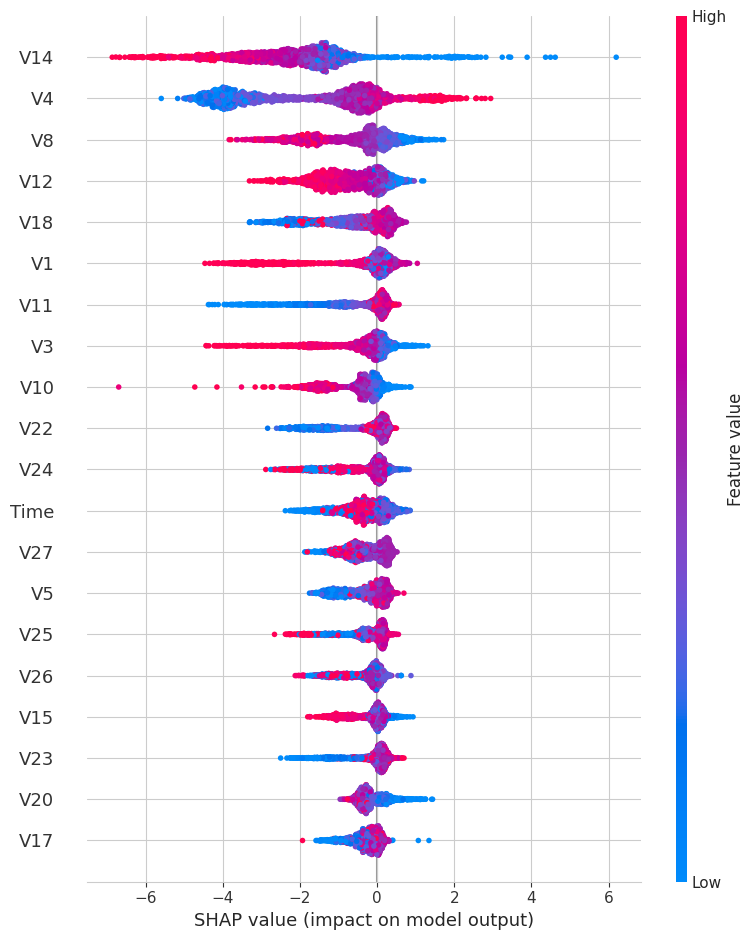

In [20]:
import shap

explainer = shap.TreeExplainer(best_model)
sample = X_test.sample(min(2000, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, show=True)


## 11. Choosing a Decision Threshold

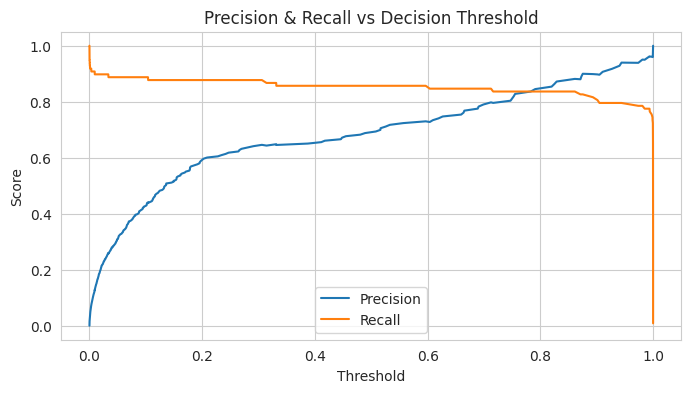

Threshold for recall >= 0.9: 0.009
  -> Precision at this threshold: 0.129


In [21]:
y_proba = best_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(thresholds, precisions[:-1], label='Precision')
ax.plot(thresholds, recalls[:-1], label='Recall')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision & Recall vs Decision Threshold')
ax.legend()
plt.show()

target_recall = 0.90
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(precisions[:-1][valid_idx])]
    chosen_threshold = thresholds[best_idx]
    print(f"Threshold for recall >= {target_recall}: {chosen_threshold:.3f}")
    print(f"  -> Precision at this threshold: {precisions[best_idx]:.3f}")


## 12. Save the Final Model

In [ ]:
import joblib

best_model.save_model('fraud_model.json')
joblib.dump({'amount': amount_scaler, 'time': time_scaler}, 'scaler.pkl'
print("Saved fraud_model.json and scaler.pkl")

from google.colab import files
files.download('scaler.pkl')

Saved fraud_model.json and scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>